# Museums per Capita: Most and Least

Self-contained notebook — needs only `museums.csv` in the same folder. Run **Kernel → Restart Kernel and Run All Cells** and it produces both answers.

**Approach**
1. Load the raw CSV.
2. Group museum counts by state, then by city.
3. Divide by 2020 Census population to get museums per 100,000 residents.
4. Report the maximum and minimum at each level.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("museums.csv", low_memory=False)

# Use admin location — physical location is missing for ~72% of rows
df = df.rename(columns={
    "City (Administrative Location)":  "city",
    "State (Administrative Location)": "state",
})
df["city"] = df["city"].str.title()  # source data is ALL CAPS

print(f"Loaded {len(df):,} museums across {df['state'].nunique()} states/territories")

Loaded 33,072 museums across 51 states/territories


## Part 1: States

### State populations (2020 US Census)

In [2]:
state_pop = {
    "AL": 5024279, "AK": 733391, "AZ": 7151502, "AR": 3011524,
    "CA": 39538223, "CO": 5773714, "CT": 3605944, "DE": 989948,
    "DC": 689545, "FL": 21538187, "GA": 10711908, "HI": 1455271,
    "ID": 1839106, "IL": 12812508, "IN": 6785528, "IA": 3190369,
    "KS": 2937880, "KY": 4505836, "LA": 4657757, "ME": 1362359,
    "MD": 6177224, "MA": 7029917, "MI": 10077331, "MN": 5706494,
    "MS": 2961279, "MO": 6154913, "MT": 1084225, "NE": 1961504,
    "NV": 3104614, "NH": 1377529, "NJ": 9288994, "NM": 2117522,
    "NY": 20201249, "NC": 10439388, "ND": 779094, "OH": 11799448,
    "OK": 3959353, "OR": 4237256, "PA": 13002700, "RI": 1097379,
    "SC": 5118425, "SD": 886667, "TN": 6910840, "TX": 29145505,
    "UT": 3271616, "VT": 643077, "VA": 8631393, "WA": 7705281,
    "WV": 1793716, "WI": 5893718, "WY": 576851,
}

### Group, divide, rank

In [3]:
counts = df["state"].value_counts().rename("museums")
pops = pd.Series(state_pop, name="population")

states = pd.concat([counts, pops], axis=1).dropna()
states["population"] = states["population"].astype(int)
states["per_100k"] = (states["museums"] / states["population"] * 100_000).round(2)
states = states.sort_values("per_100k", ascending=False)
states.head(10)

,museums,population,per_100k
VT,292,643077,45.41
ME,521,1362359,38.24
ND,269,779094,34.53
WY,192,576851,33.28
DC,190,689545,27.55
SD,234,886667,26.39
NH,363,1377529,26.35
MT,270,1084225,24.90
AK,162,733391,22.09
IA,661,3190369,20.72


### Bottom 10

In [4]:
states.tail(10).sort_values("per_100k")

,museums,population,per_100k
UT,170,3271616,5.20
FL,1149,21538187,5.33
NV,174,3104614,5.60
GA,668,10711908,6.24
AZ,449,7151502,6.28
TX,1886,29145505,6.47
CA,2670,39538223,6.75
NC,779,10439388,7.46
SC,391,5118425,7.64
TN,559,6910840,8.09


### Chart — every state ranked

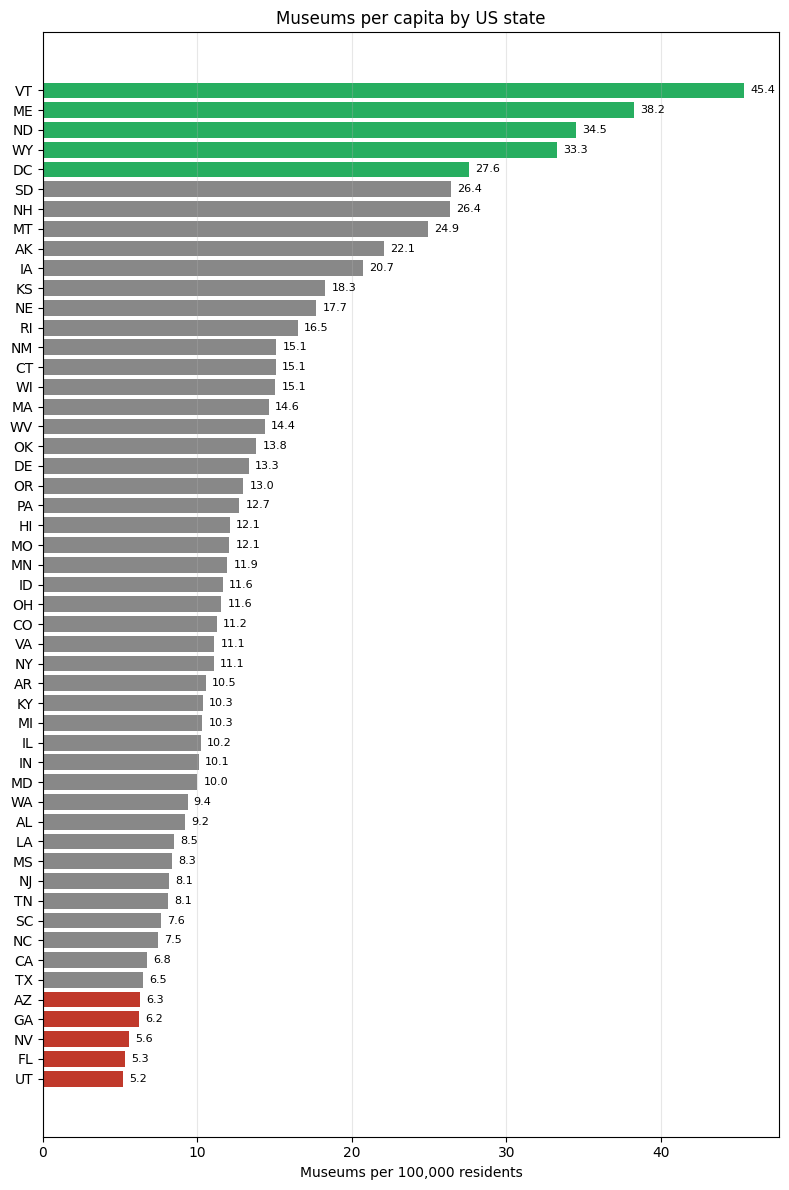

In [5]:
ranked = states.sort_values("per_100k")
colors = ["#888"] * len(ranked)
for i in range(5):
    colors[i] = "#c0392b"          # bottom 5 red
for i in range(len(ranked) - 5, len(ranked)):
    colors[i] = "#27ae60"          # top 5 green

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(ranked.index, ranked["per_100k"], color=colors)
ax.set_xlabel("Museums per 100,000 residents")
ax.set_title("Museums per capita by US state")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(ranked["per_100k"]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### Answer — states

In [6]:
top, bot = states.iloc[0], states.iloc[-1]
print(f"MOST  per capita: {top.name}  → {top['per_100k']} museums per 100k  ({int(top['museums'])} museums / {int(top['population']):,} pop)")
print(f"LEAST per capita: {bot.name}  → {bot['per_100k']} museums per 100k  ({int(bot['museums'])} museums / {int(bot['population']):,} pop)")

MOST  per capita: VT  → 45.41 museums per 100k  (292 museums / 643,077 pop)
LEAST per capita: UT  → 5.2 museums per 100k  (170 museums / 3,271,616 pop)


## Part 2: Cities

Per-capita ratios by city are dominated by tiny towns (one museum / 200 residents = 500 per 100k, which is technically the maximum but not meaningful). We restrict to the 15 cities with the most museums in absolute terms — large places where the ratio reflects something real.

In [7]:
city_counts = (df.groupby(["city", "state"]).size()
                 .rename("museums")
                 .sort_values(ascending=False)
                 .head(15))
city_counts

city           state
New York       NY       297
Chicago        IL       193
Washington     DC       188
Philadelphia   PA       179
Los Angeles    CA       162
Houston        TX       133
Baltimore      MD       120
San Francisco  CA       119
Seattle        WA       103
San Diego      CA        96
Portland       OR        96
Austin         TX        96
Dallas         TX        94
Boston         MA        93
Denver         CO        89
Name: museums, dtype: int64

In [8]:
city_pop = {
    ("New York",      "NY"): 8_804_190,
    ("Chicago",       "IL"): 2_746_388,
    ("Washington",    "DC"):   689_545,
    ("Philadelphia",  "PA"): 1_603_797,
    ("Los Angeles",   "CA"): 3_898_747,
    ("Houston",       "TX"): 2_304_580,
    ("Baltimore",     "MD"):   585_708,
    ("San Francisco", "CA"):   873_965,
    ("Seattle",       "WA"):   737_015,
    ("San Diego",     "CA"): 1_386_932,
    ("Portland",      "OR"):   652_503,
    ("Austin",        "TX"):   961_855,
    ("Dallas",        "TX"): 1_304_379,
    ("Boston",        "MA"):   675_647,
    ("Denver",        "CO"):   715_522,
}

cities = city_counts.reset_index()
cities["population"] = cities.apply(lambda r: city_pop.get((r["city"], r["state"])), axis=1)
cities["per_100k"] = (cities["museums"] / cities["population"] * 100_000).round(2)
cities = cities.sort_values("per_100k", ascending=False).reset_index(drop=True)
cities

,city,state,museums,population,per_100k
0,Washington,DC,188,689545,27.26
1,Baltimore,MD,120,585708,20.49
2,Portland,OR,96,652503,14.71
3,Seattle,WA,103,737015,13.98
4,Boston,MA,93,675647,13.76
5,San Francisco,CA,119,873965,13.62
6,Denver,CO,89,715522,12.44
7,Philadelphia,PA,179,1603797,11.16
8,Austin,TX,96,961855,9.98
9,Dallas,TX,94,1304379,7.21


### Chart

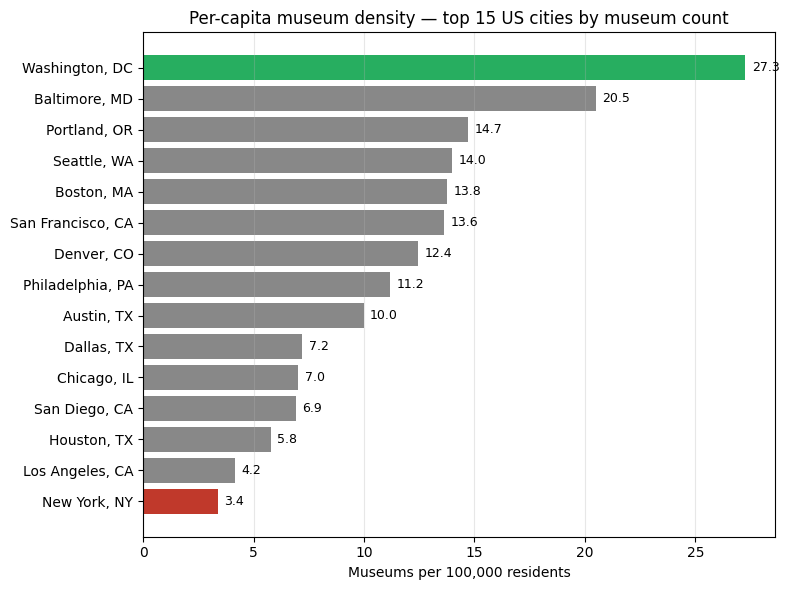

In [9]:
ranked_c = cities.sort_values("per_100k")
labels = ranked_c["city"] + ", " + ranked_c["state"]

colors = ["#888"] * len(ranked_c)
colors[0] = "#c0392b"      # least
colors[-1] = "#27ae60"     # most

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, ranked_c["per_100k"], color=colors)
ax.set_xlabel("Museums per 100,000 residents")
ax.set_title("Per-capita museum density — top 15 US cities by museum count")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(ranked_c["per_100k"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Answer — cities

In [10]:
top_c, bot_c = cities.iloc[0], cities.iloc[-1]
print(f"MOST  per capita: {top_c['city']}, {top_c['state']:2}  → {top_c['per_100k']} per 100k  ({top_c['museums']} museums / {top_c['population']:,} pop)")
print(f"LEAST per capita: {bot_c['city']}, {bot_c['state']:2}  → {bot_c['per_100k']} per 100k  ({bot_c['museums']} museums / {bot_c['population']:,} pop)")

MOST  per capita: Washington, DC  → 27.26 per 100k  (188 museums / 689,545 pop)
LEAST per capita: New York, NY  → 3.37 per 100k  (297 museums / 8,804,190 pop)


## Final answer

**Most museums per capita**
- *State*: **Vermont** — 45.4 per 100,000 (292 museums, 643k pop)
- *Major city*: **Washington, DC** — 27.3 per 100,000 (188 museums, 690k pop)

**Least museums per capita**
- *State*: **Utah** — 5.2 per 100,000 (170 museums, 3.27M pop)
- *Major city*: **New York, NY** — 3.4 per 100,000 (297 museums, 8.8M pop)

Note: New York City has the most museums of any US city in absolute terms — its low per-capita rate is purely a function of its enormous population denominator.